# 📌 Knowledge Graph

![Topic](https://img.shields.io/badge/Topic-Knowledge%20Graph-blue?style=flat-square)
![Category](https://img.shields.io/badge/Category-RAG-blueviolet?style=flat-square)
![Level](https://img.shields.io/badge/Level-Intermediate-yellow?style=flat-square)
![Last Updated](https://img.shields.io/badge/Updated-May%202026-blue?style=flat-square)
<br>
<br>
<br>
> <span style="font-size:20px;">**TL;DR** — A **knowledge graph** is a structured way to represent real-world knowledge by storing entities (people, places, concepts) as nodes and the relationships between them as edges in a graph. Unlike vector search, which finds "similar" content using math, a knowledge graph **understands how things are connected**, making it ideal for complex reasoning, explainability, and multi-hop questions.</span>

## Prerequisites

| Requirement | Details |
|-------------|---------|
| Python | 3.10+ |
| Libraries | `pip install networkx matplotlib` |
| Concepts | RAG, Vector Search |

---
## 1. Overview

<!-- What is this concept? 2–4 sentences that a newcomer could understand.
     Include: what problem it solves, why it exists, where it fits in the AI landscape. -->

A **knowledge graph** represents a **network of real-world entities**, such as objects, events, situations, or concepts. It illustrates the relationships between them. 
<br>Think of it as a map of knowledge: every fact is expressed as a triple — a subject, a predicate (relationship), and an object. For example: (Marie Curie) —[won]→ (Nobel Prize). 

Knowledge graphs are typically stored in **graph databases**, which natively store the relationships between data entities. Major companies like Google, LinkedIn, Amazon, and Facebook all use knowledge graphs to power search, recommendations, and question-answering systems. 

<br> Knowledge graphs differ from Vector search because it answers complex queries that involve hopping through several entities and relationships, like "find all employees who report to managers in the London office who joined before 2020." It **solves also the blacbox issues** of the Vector Search.

<br> They should be used when you need reasoning over complex relationships (fraud detection, supply chain), explainability (healthcare, finance), multi-hop question answering, or when integrating diverse data sources into a unified structure.

---
## 2. How It Works

<!-- Break the concept into numbered steps or subsections.
     Use diagrams (images from assets/) where helpful.
     Each subsection should follow: description → danger/difficulty level → counter-technique or note -->

The process works in four stages:
1. **Raw data** (text documents, databases, APIs) is **collected**. 
2. Entity extraction **identifies the key concepts and the relationships** between them (manually, through NLP, or using LLMs). 
3. These entities and relationships are **stored** as a graph of interconnected nodes and edges **in a graph database** like Neo4j. 
4. Users can **query the graph using languages like Cypher or SPARQL** to traverse relationships, answer complex questions, or feed structured context into an LLM (this is what GraphRAG does).

<br>Triples are broken down into three parts: subject, object, and predicate. The subject defines the concept being described, the object represents the value, and the predicate constitutes the relationship. 

![Knowledge_Graph](../assets/Knowledge_Graph.png)

---
## 3. Advantages & Limitations

| | Aspect | Commentary |
|--|--------|------------|
| 🟢 | **Explainability** | Every answer can be traced through a clear chain of entities and relationships. No Blackbox. |
| 🟢 | **Complex reasoning** | Supports multi-hop queries across many entities, e.g. "find suppliers of parts used in recalled products." |
| 🟢 | **Data integration** | Unifies structured, semi-structured, and unstructured data from diverse sources into one connected model. |
| 🔴 | **Build complexity** | Requires careful schema design, entity extraction, and ongoing maintenance  |
| 🔴 | **Scaling challenges** | Large knowledge graphs can become costly to query and maintain, especially with frequent data updates. |
| 🔴 | **Incomplete coverage** | Only captures what has been explicitly modeled — missing entities or relationships create blind spots. |
| 🔴 | **Expertise required** | Teams need familiarity with graph databases, query languages (Cypher/SPARQL), and ontology design. |

---
## 4. Code Example

> **Goal:** This script builds a small knowledge graph about scientists, their discoveries, and institutions using Python's networkx library. You can run this with: pip install networkx matplotlib

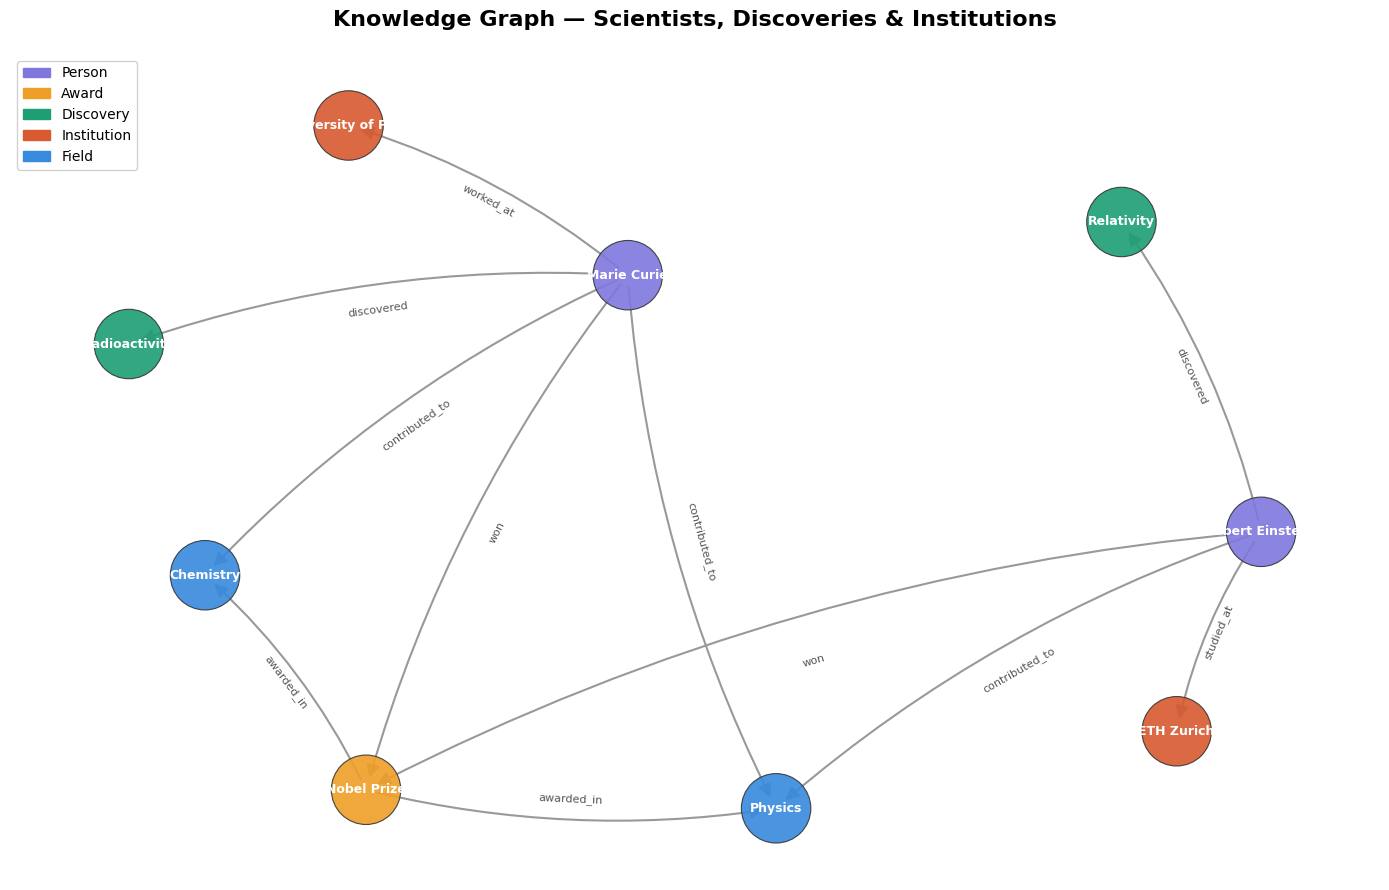

QUERY 1: What did Marie Curie discover?
  → Radioactivity

QUERY 2: Who won the Nobel Prize?
  → Marie Curie
  → Albert Einstein

QUERY 3: Fields linked to Nobel Prize winners (multi-hop)
  Marie Curie → Physics, Chemistry
  Albert Einstein → Physics

QUERY 4: All connections of 'Marie Curie'
  Marie Curie --[discovered]--> Radioactivity
  Marie Curie --[won]--> Nobel Prize
  Marie Curie --[worked_at]--> University of Paris
  Marie Curie --[contributed_to]--> Physics
  Marie Curie --[contributed_to]--> Chemistry

Graph stats:
  Entities (nodes): 9
  Relationships (edges): 11
  Entity types: {'Institution', 'Award', 'Field', 'Person', 'Discovery'}


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -------------------------------------------------------
# STEP 1: Create an empty directed graph
# -------------------------------------------------------
# A knowledge graph is a directed graph where:
#   - Nodes = entities (people, places, concepts)
#   - Edges = relationships between entities
kg = nx.DiGraph()

# -------------------------------------------------------
# STEP 2: Add entities (nodes) with attributes
# -------------------------------------------------------
# Each node has a "type" attribute to classify it
kg.add_node("Marie Curie",      type="Person",      field="Physics & Chemistry")
kg.add_node("Albert Einstein",  type="Person",      field="Physics")
kg.add_node("Nobel Prize",      type="Award")
kg.add_node("Radioactivity",    type="Discovery")
kg.add_node("Relativity",       type="Discovery")
kg.add_node("University of Paris", type="Institution")
kg.add_node("ETH Zurich",       type="Institution")
kg.add_node("Physics",          type="Field")
kg.add_node("Chemistry",        type="Field")

# -------------------------------------------------------
# STEP 3: Add relationships (edges) — these form "triples"
# -------------------------------------------------------
# A triple = (Subject) --[Predicate]--> (Object)
# Example: (Marie Curie) --[discovered]--> (Radioactivity)

kg.add_edge("Marie Curie",     "Radioactivity",       relation="discovered")
kg.add_edge("Marie Curie",     "Nobel Prize",         relation="won")
kg.add_edge("Marie Curie",     "University of Paris", relation="worked_at")
kg.add_edge("Marie Curie",     "Physics",             relation="contributed_to")
kg.add_edge("Marie Curie",     "Chemistry",           relation="contributed_to")

kg.add_edge("Albert Einstein", "Relativity",          relation="discovered")
kg.add_edge("Albert Einstein", "Nobel Prize",         relation="won")
kg.add_edge("Albert Einstein", "ETH Zurich",          relation="studied_at")
kg.add_edge("Albert Einstein", "Physics",             relation="contributed_to")

kg.add_edge("Nobel Prize",     "Physics",             relation="awarded_in")
kg.add_edge("Nobel Prize",     "Chemistry",           relation="awarded_in")

# -------------------------------------------------------
# STEP 4: Draw the graph
# -------------------------------------------------------
color_map = {
    "Person":      "#7F77DD",  # purple
    "Award":       "#EF9F27",  # amber
    "Discovery":   "#1D9E75",  # teal
    "Institution": "#D85A30",  # coral
    "Field":       "#378ADD",  # blue
}
 
node_colors = [color_map.get(kg.nodes[n].get("type", ""), "#888") for n in kg.nodes]


plt.figure(figsize=(14, 9))
plt.title("Knowledge Graph — Scientists, Discoveries & Institutions", 
          fontsize=16, fontweight="bold", pad=20)
 
# Layout: spring layout spreads nodes nicely
pos = nx.spring_layout(kg, seed=42, k=2.5)
 
# Draw nodes
nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=2500, 
                        edgecolors="#333", linewidths=0.8, alpha=0.9)
 
# Draw labels inside nodes
nx.draw_networkx_labels(kg, pos, font_size=9, font_weight="bold", font_color="white")
 
# Draw edges (arrows)
nx.draw_networkx_edges(kg, pos, edge_color="#999", arrows=True, 
                        arrowsize=20, arrowstyle="-|>", 
                        connectionstyle="arc3,rad=0.1", width=1.5)
 
# Draw edge labels (relationship names)
edge_labels = nx.get_edge_attributes(kg, "relation")
nx.draw_networkx_edge_labels(kg, pos, edge_labels=edge_labels, 
                              font_size=8, font_color="#555",
                              bbox=dict(boxstyle="round,pad=0.2", 
                                        fc="white", ec="none", alpha=0.8))
 
# Legend
legend_handles = [mpatches.Patch(color=color, label=label) 
                  for label, color in color_map.items()]
plt.legend(handles=legend_handles, loc="upper left", fontsize=10, 
           framealpha=0.9, edgecolor="#ccc")
 
plt.axis("off")
plt.tight_layout()
plt.show()
# -------------------------------------------------------
# STEP 5: Query the knowledge graph
# -------------------------------------------------------

# QUERY 1: What did Marie Curie discover?
print("=" * 50)
print("QUERY 1: What did Marie Curie discover?")
print("=" * 50)
for _, target, data in kg.out_edges("Marie Curie", data=True):
    if data["relation"] == "discovered":
        print(f"  → {target}")

# QUERY 2: Who won the Nobel Prize? (reverse traversal)
print("\nQUERY 2: Who won the Nobel Prize?")
print("=" * 50)
for source, _, data in kg.in_edges("Nobel Prize", data=True):
    if data["relation"] == "won":
        print(f"  → {source}")

# QUERY 3: Multi-hop — What fields are linked to Nobel Prize winners?
# This is where knowledge graphs shine vs vector search!
print("\nQUERY 3: Fields linked to Nobel Prize winners (multi-hop)")
print("=" * 50)
# Step A: Find all Nobel Prize winners
winners = [src for src, _, d in kg.in_edges("Nobel Prize", data=True)
           if d["relation"] == "won"]

# Step B: For each winner, find their fields
for winner in winners:
    fields = [tgt for _, tgt, d in kg.out_edges(winner, data=True)
              if d["relation"] == "contributed_to"]
    print(f"  {winner} → {', '.join(fields)}")

# QUERY 4: Find all connections of a given entity
print("\nQUERY 4: All connections of 'Marie Curie'")
print("=" * 50)
for _, target, data in kg.out_edges("Marie Curie", data=True):
    print(f"  Marie Curie --[{data['relation']}]--> {target}")

# -------------------------------------------------------
# STEP 6: Graph statistics
# -------------------------------------------------------
print(f"\n{'=' * 50}")
print(f"Graph stats:")
print(f"  Entities (nodes): {kg.number_of_nodes()}")
print(f"  Relationships (edges): {kg.number_of_edges()}")
print(f"  Entity types: {set(nx.get_node_attributes(kg, 'type').values())}")

---
## 5. Key Takeaways
<div style="font-size: 16px; line-height: 1.6;">

- **A knowledge graph is a structured map of knowledge.**
- **Vector search finds similarity and knowledge graphs find connections.**
- **The real power of knowledge graphs is multi-hop reasoning.**
- **The best systems combine both.** Modern enterprise architectures use knowledge graphs for structured reasoning and explainability alongside vector search for fast semantic retrieval, getting the best of both worlds.


</div>